In [1]:
import numpy as np
import pandas as pd

from sklearn.metrics import confusion_matrix

from analysis_shared_functions import (
    bulk_vs_singlecell_matrix_viz, 
    all_samples_matrix_viz,
    parse_heatmap_matrix_crosscheckfingerprints,
    long_df_to_matrix_crosscheckfingerprints,
    parse_sample_matching_results_crosscheckfingerprints
)

In [2]:
DATA_PATH = "../../data/output_data/"
FIGURES_PATH = "../../data/figures/"
tool = "CrosscheckFingerprints"
dataset = "low_grade_glioma"
pseudobulk = True
ncells = 500000
rd = 1

# Data munging

In [3]:
df, matrix = parse_heatmap_matrix_crosscheckfingerprints(DATA_PATH, pseudobulk, dataset, ncells, rd)

In [4]:
df.head()

,LEFT_SAMPLE,RIGHT_SAMPLE,LOD_SCORE,RESULT
0,pseudobulk_GSM7326894_ncells_500000_3,pseudobulk_GSM7326894_ncells_500000_3,15.275309,EXPECTED_MATCH
1,pseudobulk_GSM7326894_ncells_500000_3,pseudobulk_GSM7326880_ncells_500000_2,0.000000,INCONCLUSIVE
2,pseudobulk_GSM7326894_ncells_500000_3,pseudobulk_GSM7326888_ncells_500000_1,0.353664,UNEXPECTED_MATCH
3,pseudobulk_GSM7326894_ncells_500000_3,pseudobulk_GSM7326891_ncells_500000_2,0.565772,UNEXPECTED_MATCH
4,pseudobulk_GSM7326894_ncells_500000_3,pseudobulk_GSM7326901_ncells_500000_3,-3.725188,EXPECTED_MISMATCH


In [5]:
matrix.head()

,pseudobulk_GSM7326880_ncells_500000_1,pseudobulk_GSM7326880_ncells_500000_2,pseudobulk_GSM7326880_ncells_500000_3,pseudobulk_GSM7326881_ncells_500000_1,pseudobulk_GSM7326881_ncells_500000_2,pseudobulk_GSM7326881_ncells_500000_3,pseudobulk_GSM7326883_ncells_500000_1,pseudobulk_GSM7326883_ncells_500000_2,pseudobulk_GSM7326883_ncells_500000_3,pseudobulk_GSM7326884_ncells_500000_1,...,pseudobulk_GSM7326901_ncells_500000_3,pseudobulk_GSM7326902_ncells_500000_1,pseudobulk_GSM7326902_ncells_500000_2,pseudobulk_GSM7326902_ncells_500000_3,pseudobulk_GSM7326903_ncells_500000_1,pseudobulk_GSM7326903_ncells_500000_2,pseudobulk_GSM7326903_ncells_500000_3,pseudobulk_GSM7326905_ncells_500000_1,pseudobulk_GSM7326905_ncells_500000_2,pseudobulk_GSM7326905_ncells_500000_3
LEFT_SAMPLE,,,,,,,,,,,,,,,,,,,,,
pseudobulk_GSM7326880_ncells_500000_1,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,...,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
pseudobulk_GSM7326880_ncells_500000_2,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,...,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
pseudobulk_GSM7326880_ncells_500000_3,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,...,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
pseudobulk_GSM7326881_ncells_500000_1,0.0,0.0,0.0,0.144183,0.144183,0.144183,0.136719,0.136719,0.136719,0.0,...,-1.58695,0.146556,0.146556,0.146556,0.035495,0.035495,0.035495,0.146556,0.146556,0.146556
pseudobulk_GSM7326881_ncells_500000_2,0.0,0.0,0.0,0.144183,0.144183,0.144183,0.136719,0.136719,0.136719,0.0,...,-1.58695,0.146556,0.146556,0.146556,0.035495,0.035495,0.035495,0.146556,0.146556,0.146556


In [6]:
df["RESULT"].value_counts()["INCONCLUSIVE"]/df.shape[0]

np.float64(0.16735537190082644)

In [3]:
inferred_matches = parse_sample_matching_results_crosscheckfingerprints(DATA_PATH, pseudobulk, dataset, ncells, rd)
inferred_matches.head()

RESULT
LEFT_SAMPLE                           RIGHT_SAMPLE                                
pseudobulk_GSM7326894_ncells_500000_3 pseudobulk_GSM7326894_ncells_500000_3      1
                                      pseudobulk_GSM7326880_ncells_500000_2    NaN
                                      pseudobulk_GSM7326888_ncells_500000_1      1
                                      pseudobulk_GSM7326891_ncells_500000_2      1
                                      pseudobulk_GSM7326901_ncells_500000_3      0

In [4]:
len(inferred_matches)

4356

# Real data viz & analysis

In [ ]:
bulk_vs_singlecell_matrix_viz(
    matrix,
    pseudobulk=pseudobulk,
    tool=tool,
    dataset=dataset,
    ncells=ncells,
    rd=rd,
    save_fig=False
)

## Comparison with expected matches

In [ ]:
expected_matches_df = pd.read_csv(
    DATA_PATH + f"../metadata/sample_matches/sample_matches_{dataset}.csv"
).dropna(how="all", axis=1).dropna(how="any")

# Pseudobulk viz & analysis

In [ ]:
# Filter CrosscheckFingerprints matrix to only samples ending in _1 in rows and samples ending in _2 in columns
pseudobulk_1 = "_1"
pseudobulk_2 = "_2"
pseudobulk_regex = r"_[1-3]{1}$"
matrix_filtered = matrix.loc[
    [idx for idx in matrix.index if idx.endswith(pseudobulk_1)],
    [col for col in matrix.columns if col.endswith(pseudobulk_2)]
]

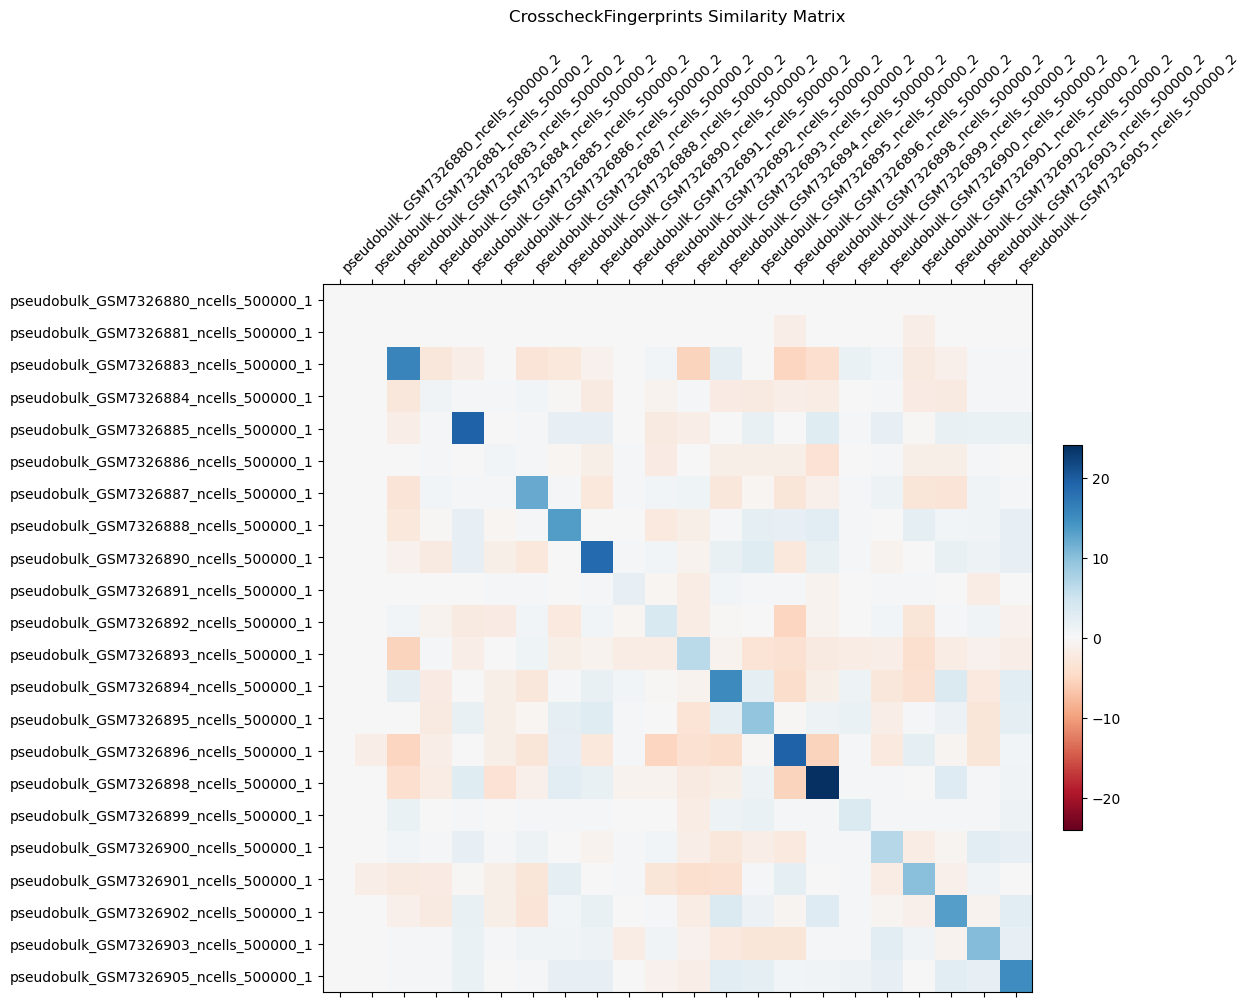

In [ ]:
all_samples_matrix_viz(
    matrix_filtered, 
    pseudobulk=pseudobulk, 
    tool=tool, 
    dataset=dataset, 
    ncells=ncells, 
    rd=rd, 
    save_fig=True,
    FIGURES_PATH=FIGURES_PATH
)

## Detailed accuracy metrics

In [14]:
# Create inferred_matches matrix for submatrix 
inferred_matches_submatrix = inferred_matches.loc[
    [idx for idx in inferred_matches.index if idx.endswith(pseudobulk_1)],
    [col for col in inferred_matches.columns if col.endswith(pseudobulk_2)]
]
inferred_matches_submatrix.columns = pd.Index(inferred_matches_submatrix.columns, name="RIGHT_SAMPLE")

In [15]:
inferred_matches_submatrix.head()

RIGHT_SAMPLE,pseudobulk_GSM7326880_ncells_500000_2,pseudobulk_GSM7326881_ncells_500000_2,pseudobulk_GSM7326883_ncells_500000_2,pseudobulk_GSM7326884_ncells_500000_2,pseudobulk_GSM7326885_ncells_500000_2,pseudobulk_GSM7326886_ncells_500000_2,pseudobulk_GSM7326887_ncells_500000_2,pseudobulk_GSM7326888_ncells_500000_2,pseudobulk_GSM7326890_ncells_500000_2,pseudobulk_GSM7326891_ncells_500000_2,...,pseudobulk_GSM7326894_ncells_500000_2,pseudobulk_GSM7326895_ncells_500000_2,pseudobulk_GSM7326896_ncells_500000_2,pseudobulk_GSM7326898_ncells_500000_2,pseudobulk_GSM7326899_ncells_500000_2,pseudobulk_GSM7326900_ncells_500000_2,pseudobulk_GSM7326901_ncells_500000_2,pseudobulk_GSM7326902_ncells_500000_2,pseudobulk_GSM7326903_ncells_500000_2,pseudobulk_GSM7326905_ncells_500000_2
LEFT_SAMPLE,,,,,,,,,,,,,,,,,,,,,
pseudobulk_GSM7326880_ncells_500000_1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
pseudobulk_GSM7326881_ncells_500000_1,0,1,1,0,1,0,1,0,1,0,...,1,1,0,1,0,1,0,1,1,1
pseudobulk_GSM7326883_ncells_500000_1,0,1,1,0,0,0,0,0,0,0,...,1,0,0,0,1,1,0,0,1,1
pseudobulk_GSM7326884_ncells_500000_1,0,0,0,1,1,1,1,0,0,0,...,0,0,0,0,0,1,0,0,1,1
pseudobulk_GSM7326885_ncells_500000_1,0,1,0,1,1,0,1,1,1,0,...,1,1,1,1,1,1,0,1,1,1


In [16]:
# Create true_matches matrix for submatrix 
# Matches on the diagonal (1), the rest non-matches (0)
true_matches = pd.DataFrame(
    np.identity(len(inferred_matches_submatrix)),
    index=pd.Index(inferred_matches_submatrix.index, name="pseudobulk_1"), 
    columns=pd.Index(inferred_matches_submatrix.columns, name="pseudobulk_2"),
    )

In [17]:
# Melt matrices into long form 
true_matches_long = true_matches.stack().rename("match").reset_index().set_index(["pseudobulk_1", "pseudobulk_2"])
inferred_matches_long = inferred_matches_submatrix.stack().rename("match").reset_index().set_index(["LEFT_SAMPLE", "RIGHT_SAMPLE"])

inferred_matches_long["match"] = inferred_matches_long["match"].astype(float)

In [18]:
# Calculate confusion matrix
tn, fp, fn, tp = confusion_matrix(true_matches_long, inferred_matches_long).ravel().tolist()

In [19]:
accuracy = (tp + tn) / (tp + tn + fp + fn)
tpr = tp / (tp + fn)
tnr = tn / (tn + fp)
balanced_accuracy = (tpr + tnr) / 2
precision = tp / (tp + fp)
recall = tp / (tp + fn)
f1 = 2 * precision * recall / (precision + recall)

print(f"Accuracy = {accuracy:.2f}")
print(f"Balanced accuracy = {balanced_accuracy:.2f}")
print(f"Precision = {precision:.2f}")
print(f"Recall = {recall:.2f}")
print(f"F1 = {f1:.2f}")

Accuracy = 0.55
Balanced accuracy = 0.74
Precision = 0.09
Recall = 0.95
F1 = 0.16
